CHESS BOT !!!!!

In [1]:
!pip install python-chess












[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
from chess import pgn
from tqdm import tqdm
import chess

import numpy as np
from chess import Board
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

In [2]:
from pathlib import Path

folder_path = Path(r"F:\Chess_Bot\Lichess Elite Database")

In [3]:
import os

folder_path = r"F:\Chess_Bot"
print(os.listdir(folder_path))


['Backend', 'Frontend']


In [4]:
import os

folder_path = r"F:\Chess_Bot\Backend\Lichess Elite Database"
for f in os.listdir(folder_path):
    print(f)


1 - READ ME.txt
lichess_elite_2013-09.pgn
lichess_elite_2013-11.pgn
lichess_elite_2014-01.pgn
lichess_elite_2014-02.pgn
lichess_elite_2014-03.pgn
lichess_elite_2014-04.pgn
lichess_elite_2014-05.pgn
lichess_elite_2014-06.pgn
lichess_elite_2014-07.pgn
lichess_elite_2014-08.pgn
lichess_elite_2014-09.pgn
lichess_elite_2014-10.pgn
lichess_elite_2014-11.pgn
lichess_elite_2014-12.pgn
lichess_elite_2015-01.pgn
lichess_elite_2015-02.pgn
lichess_elite_2015-03.pgn
lichess_elite_2015-04.pgn
lichess_elite_2015-05.pgn
lichess_elite_2015-06.pgn
lichess_elite_2015-07.pgn
lichess_elite_2015-08.pgn
lichess_elite_2015-09.pgn
lichess_elite_2015-10.pgn
lichess_elite_2015-11.pgn
lichess_elite_2015-12.pgn
lichess_elite_2016-01.pgn
lichess_elite_2016-02.pgn
lichess_elite_2016-03.pgn
lichess_elite_2016-04.pgn
lichess_elite_2016-05.pgn
lichess_elite_2016-06.pgn
lichess_elite_2016-07.pgn
lichess_elite_2016-08.pgn
lichess_elite_2016-09.pgn
lichess_elite_2016-10.pgn
lichess_elite_2016-11.pgn
lichess_elite_2016-12.

Load Game

In [5]:
def load_pgn(file_path):

    games=[]
    with open(file_path,'r') as pgn_file:
        while True:
            game=pgn.read_game(pgn_file)
            if game is None:
                break
            games.append(game)
    return games

In [6]:
import os
from tqdm import tqdm

pgn_folder = r"F:\Chess_Bot\Backend\Lichess Elite Database"
files = [f for f in os.listdir(pgn_folder) if f.endswith(".pgn")]

Limit_of_files = min(len(files), 35)
files = sorted(files, key=lambda f: os.path.getsize(os.path.join(pgn_folder, f)))

games = []
for i, file in enumerate(tqdm(files, total=Limit_of_files), start=1):
    file_path = os.path.join(pgn_folder, file)
    games.extend(load_pgn(file_path))
    if i >= Limit_of_files:
        break


 97%|█████████▋| 34/35 [10:51<00:19, 19.17s/it]


PREPERATION....

Board to Matrix

In [1]:
def Board_To_Matrix(board:Board):
    matrix = np.zeros((8,8,12))              #12-> ♖♘♗♔♕♗♘♖♜♞♝♚♛♝♞♜
    piece_map = board.piece_map()            #Dictuanry of key->square indesis(63 = h8).  :value->chess.Piece objects (like a white pawn, black rook, etc.)
    #0: Piece.from_symbol('r'),
    #Lowercase = black pieces (r, n, b, q, k, p).
	#Uppercase = white pieces (R, N, B, Q, K, P).
    for square,piece in piece_map.items():
        row,col =divmod(square,8)
        piece_type=piece.piece_type -1
        piece_colour= 0 if piece.color else 6
        matrix[row, col, piece_type+piece_colour]=1
    return matrix

NameError: name 'Board' is not defined

Input for Neural Network

In [8]:
def create_input_for_nn (games) :
    x=[]                            # this will collect the position boards of the game from starting to the end of the game
    y=[]                            # the moves which were played (notations to uci) in the uci format
    for game in games:
        board= game.board()
        for move in game.mainline_moves():
            x.append(Board_To_Matrix(board))
            y.append(move.uci())
            board.push(move)
    return x,y

Encodes Moves

In [9]:
def encode_moves(moves):        # convert moves from uci format to natural numbers
    move_to_int = { move: idx for idx,move in enumerate(set(moves)) }
    return [move_to_int[move] for move in moves],move_to_int
    #       list of moves after,maping itself

Neural Network

In [ ]:
X,y =create_input_for_nn(games)
y,move_to_int = encode_moves(y)
y =to_categorical(y,num_classes=len(move_to_int))
X =np.array(X)

In [ ]:
print(X.shape)
print(y.shape)

(199828, 8, 8, 12)
(199828, 1828)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=1,      # 40% for testing
)

In [ ]:
pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: scikit-learn in f:\new folder\python\lib\site-packages (1.7.2)




[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
!pip install pandas


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
pip install pandas scikit-learn opencv-python


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:

print(X_train.shape)
print(y_train.shape)

(119896, 8, 8, 12)
(119896, 1828)


In [ ]:
print(X_train)

[[[[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]]

  [[1. 0. 0. ... 0. 0. 0.]
   [1. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [1. 0. 0. ... 0. 0. 0.]
   [1. 0. 0. ... 0. 0. 0.]
   [1. 0. 0. ... 0. 0. 0.]]

  [[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]]

  ...

  [[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]]

  [[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]]

  [[0. 0. 0. ... 1. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 1. 0. 0.]
   [0. 0. 0. ... 0. 0. 

In [ ]:
model=Sequential([
    #Input Layer
    Conv2D(64,(3,3), activation='relu', input_shape=(8,8,12)),
    Conv2D(128,(3,3),activation='relu'),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(len(move_to_int), activation='softmax')
])

f:\New folder\python\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()
model.fit(X_train, y_train, epochs=5, validation_split=0.1, batch_size=64)
# model.save("model/chess_model.keras")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 6, 6, 64)       │         6,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1828)           │       469,796 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,075,172 (4.10 MB)

 Trainable params: 1,075,172 (4.10 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.0567 - loss: 6.1192 - val_accuracy: 0.0936 - val_loss: 5.7497
Epoch 2/5
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.1114 - loss: 5.3749 - val_accuracy: 0.1212 - val_loss: 5.3215
Epoch 3/5
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.1479 - loss: 4.7802 - val_accuracy: 0.1384 - val_loss: 5.1506
Epoch 4/5
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.1759 - loss: 4.3170 - val_accuracy: 0.1429 - val_loss: 5.0833
Epoch 5/5
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.2038 - loss: 3.9374 - val_accuracy: 0.1464 - val_loss: 5.1753


Save Model

In [ ]:
model.save("my_chess_model_2_75.keras")


In [ ]:
model.save(r"F:\Chess_Bot\my_chess_model_2_75.keras")


Move to Int

In [ ]:
import pickle

# Save the dictionary locally
with open(r"F:\Chess_Bot\move_to_int.pkl", "wb") as f:
    pickle.dump(move_to_int, f)

print("✅ Dictionary saved to F:\\Chess_Bot\\move_to_int.pkl")


✅ Dictionary saved to F:\Chess_Bot\move_to_int.pkl


In [ ]:
print(move_to_int)

{'f1d3': 0, 'f5c5': 1, 'g7e8': 2, 'a6d3': 3, 'd7b8': 4, 'h2d2': 5, 'a3e7': 6, 'a7h7': 7, 'b4b3': 8, 'f5c8': 9, 'b3f7': 10, 'a2a6': 11, 'e8c7': 12, 'b7d6': 13, 'a6a8': 14, 'b8b5': 15, 'g6d6': 16, 'h2f3': 17, 'a7a2': 18, 'h5h2': 19, 'f4h4': 20, 'a7f7': 21, 'a8a4': 22, 'a3b4': 23, 'a5c7': 24, 'b3g3': 25, 'f8b8': 26, 'e5g7': 27, 'e8h5': 28, 'g4h4': 29, 'd3c1': 30, 'e2g4': 31, 'f3b7': 32, 'd6d5': 33, 'a2e2': 34, 'a7d4': 35, 'c6b7': 36, 'c6b6': 37, 'f7a7': 38, 'b7g2': 39, 'f2e3': 40, 'b3d3': 41, 'c2c4': 42, 'g2g1': 43, 'b5c4': 44, 'b2g7': 45, 'd1g4': 46, 'c3d2': 47, 'a6d6': 48, 'd7f5': 49, 'b5b8': 50, 'b3a4': 51, 'd8g8': 52, 'c6f3': 53, 'e5e2': 54, 'g7c3': 55, 'e7a7': 56, 'f2c2': 57, 'h5g5': 58, 'b4g4': 59, 'h3f3': 60, 'h7h8': 61, 'd7e7': 62, 'e5e1': 63, 'f3d3': 64, 'c8h3': 65, 'g1d4': 66, 'a5a3': 67, 'e3e8': 68, 'e1f1': 69, 'e3g3': 70, 'f3c6': 71, 'c1a1': 72, 'f8g7': 73, 'a1a6': 74, 'a4d1': 75, 'b5b1': 76, 'g1f3': 77, 'a1h1': 78, 'c3g3': 79, 'h4d4': 80, 'g2g6': 81, 'e7e6': 82, 'a1g1': 83, '

Predict

In [ ]:
int_to_move = dict(zip(move_to_int.values(), move_to_int.keys()))


def predict_next_move(board):
    board_matrix = Board_To_Matrix(board).reshape(1, 8, 8, 12)
    predictions = model.predict(board_matrix)[0]
    legal_moves = list(board.legal_moves)
    legal_moves_uci = [move.uci() for move in legal_moves]
    sorted_indices = np.argsort(predictions)[::-1]
    for move_index in sorted_indices:
        move = int_to_move[move_index]
        if move in legal_moves_uci:
            return move
    return None

In [ ]:
board = Board()

Board before prediction:


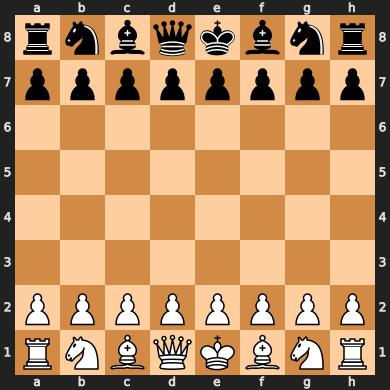

In [ ]:
print("Board before prediction:")
board

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

Predicted move: e4d5
Board after prediction:


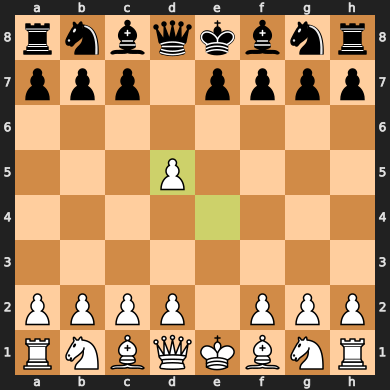

In [ ]:
# Predict and make the move
next_move = predict_next_move(board)
board.push_uci(next_move)

# Display the board after prediction
print("\nPredicted move:", next_move)
print("Board after prediction:")
board

In [ ]:
print(str(pgn.Game.from_board(board)))

[Event "?"]
[Site "?"]
[Date "????.??.??"]
[Round "?"]
[White "?"]
[Black "?"]
[Result "*"]

1. e4 d5 2. exd5 *


In [ ]:
import pickle
from tensorflow.keras.models import load_model

# Example: save model
model.save("my_chess_model_2_75.keras")

# Example: save dictionary
with open("move_to_int.pkl", "wb") as f:
    pickle.dump(move_to_int, f)
